# SET UP ĐƯỜNG DẪN VÀ FILES DỮ LIỆU

In [10]:
import os
base_path = ''
data_path = os.path.join(base_path, 'dataset')
customers = os.path.join(data_path, 'customers.csv')
orders = os.path.join(data_path, 'orders.csv')
geography = os.path.join(data_path, 'geography.csv')
sales = os.path.join(data_path, 'sales.csv')
payments = os.path.join(data_path, 'payments.csv')
products_path = os.path.join(data_path, 'products.csv')
promotions_path = os.path.join(data_path, 'promotions.csv')
shipments_path = os.path.join(data_path, 'shipments.csv')
returns_path = os.path.join(data_path, 'returns.csv')
order_items_path = os.path.join(data_path, 'order_items.csv')
inventory_path = os.path.join(data_path, 'inventory.csv')

# LOAD THƯ VIỆN CẦN THIẾT

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from bokeh.plotting import figure, show
import geopandas as gpd
import folium
import missingno as msno
from utils.export_helpers import save_plot, save_dataframe, save_results

In [11]:
df_customers = pd.read_csv(customers)
df_orders = pd.read_csv(orders)
df_geography = pd.read_csv(geography)
df_sales = pd.read_csv(sales)
df_payments = pd.read_csv(payments)
df_products = pd.read_csv(products_path)
df_promotions = pd.read_csv(promotions_path)
df_shipments = pd.read_csv(shipments_path)
df_returns = pd.read_csv(returns_path)
df_order_items = pd.read_csv(order_items_path)
df_inventory = pd.read_csv(inventory_path)

/var/folders/z1/p74bwhsn1f948c6n22t_8q6w0000gn/T/ipykernel_84308/2263424393.py:10: DtypeWarning: Columns (0: promo_id_2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_order_items = pd.read_csv(order_items_path)


# VISUALIZATION

# products.csv

In [12]:
# 1. Thêm cột Gross Profit và Gross Margin Percentage
df_products['gross_profit'] = df_products['price'] - df_products['cogs']
df_products['gross_margin_pct'] = (df_products['price'] - df_products['cogs']) / df_products['price']

# 2. Descriptive Analysis cho price, cogs, gross margin percentage
descriptive_stats = df_products[['price', 'cogs', 'gross_margin_pct']].describe().T
descriptive_stats['median'] = df_products[['price', 'cogs', 'gross_margin_pct']].median()
display(descriptive_stats)

,count,mean,std,min,25%,50%,75%,max,median
price,2412.0,4928.216231,4776.737669,9.056594,59.444924,4399.605000,7720.513784,40950.0000,4399.605000
cogs,2412.0,3868.346732,3878.584151,5.183829,35.066367,3184.934093,5864.916462,38902.5000,3184.934093
gross_margin_pct,2412.0,0.265873,0.151148,0.050000,0.104000,0.305850,0.401166,0.4996,0.305850


In [13]:
# 3. Tổng hợp theo Category
category_analysis = df_products.groupby('category').agg(
    n_products=('product_id', 'count'),
    avg_price=('price', 'mean'),
    avg_cogs=('cogs', 'mean'),
    avg_gross_margin_pct=('gross_margin_pct', 'mean'),
    median_gross_margin_pct=('gross_margin_pct', 'median')
).reset_index()

# Sắp xếp để tìm insight
category_analysis = category_analysis.sort_values(by='n_products', ascending=False)

print("Bảng phân tích theo Category:")
display(category_analysis)

# Nhận định nhanh:
most_sku_cat = category_analysis.iloc[0]['category']
profit_engine = category_analysis.sort_values(by='avg_gross_margin_pct', ascending=False).iloc[0]['category']
traffic_cat = category_analysis.sort_values(by=['n_products', 'avg_gross_margin_pct'], ascending=[False, True]).iloc[0]['category']

print(f"- Category có nhiều SKU nhất: {most_sku_cat}")
print(f"- Category là Profit Engine (Margin cao nhất): {profit_engine}")
print(f"- Category tiềm năng là Traffic/Volume (SKU nhiều nhưng margin thấp): {traffic_cat}")

Bảng phân tích theo Category:


,category,n_products,avg_price,avg_cogs,avg_gross_margin_pct,median_gross_margin_pct
3,Streetwear,1320,6765.108640,5307.287320,0.263853,0.29840
2,Outdoor,743,2481.150322,1962.268590,0.269355,0.31200
0,Casual,201,3910.085887,3027.657013,0.284754,0.34880
1,GenZ,148,2212.785086,1745.327245,0.240758,0.22475


- Category có nhiều SKU nhất: Streetwear
- Category là Profit Engine (Margin cao nhất): Casual
- Category tiềm năng là Traffic/Volume (SKU nhiều nhưng margin thấp): Streetwear


/var/folders/z1/p74bwhsn1f948c6n22t_8q6w0000gn/T/ipykernel_84308/1187078309.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='gross_margin_pct', data=df_products, palette='viridis')
/var/folders/z1/p74bwhsn1f948c6n22t_8q6w0000gn/T/ipykernel_84308/1187078309.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category', y='gross_margin_pct', data=avg_margin_data, palette='magma')


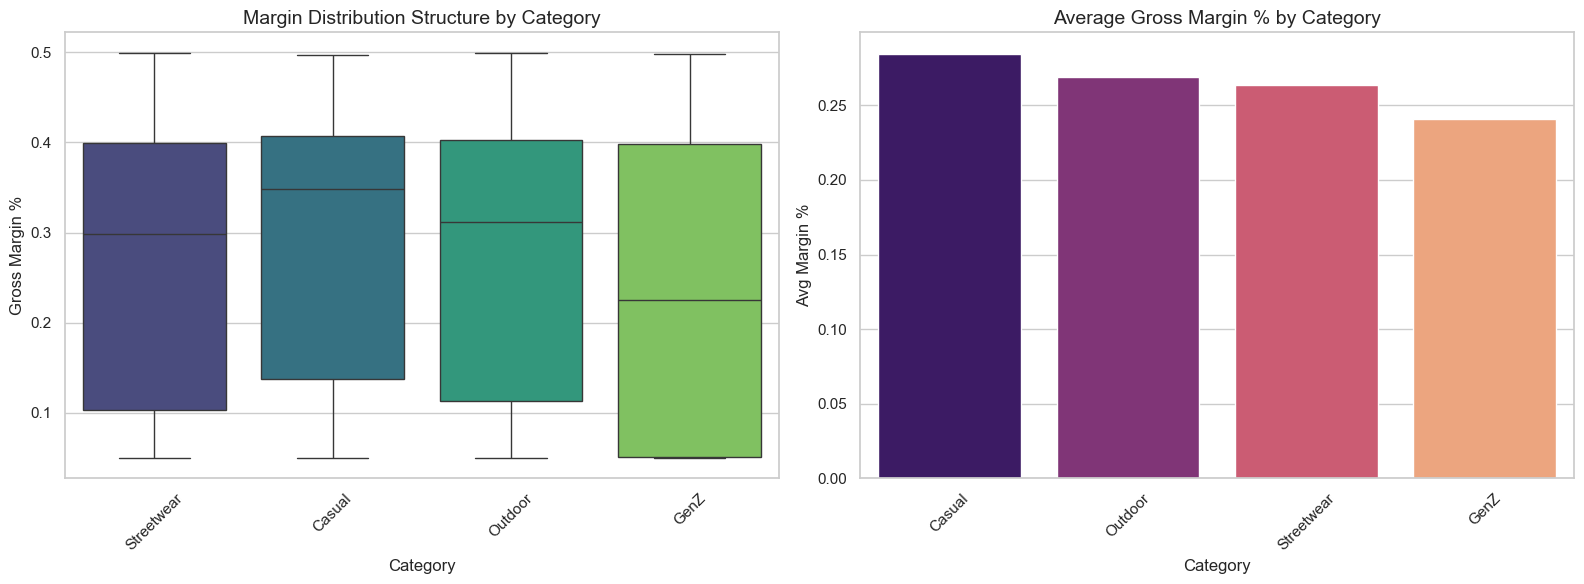

In [14]:
# Thiết lập style cho biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 6))

# 1. Boxplot: Xem phân phối và các điểm dị biệt (outliers) của Margin theo Category
plt.subplot(1, 2, 1)
sns.boxplot(x='category', y='gross_margin_pct', data=df_products, palette='viridis')
plt.title('Margin Distribution Structure by Category', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Gross Margin %', fontsize=12)
plt.xticks(rotation=45)

# 2. Bar chart: So sánh tỷ lệ Margin trung bình
plt.subplot(1, 2, 2)
avg_margin_data = df_products.groupby('category')['gross_margin_pct'].mean().sort_values(ascending=False).reset_index()
sns.barplot(x='category', y='gross_margin_pct', data=avg_margin_data, palette='magma')
plt.title('Average Gross Margin % by Category', fontsize=14)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Avg Margin %', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Pivot Table: Mean Gross Margin % by Category and Size


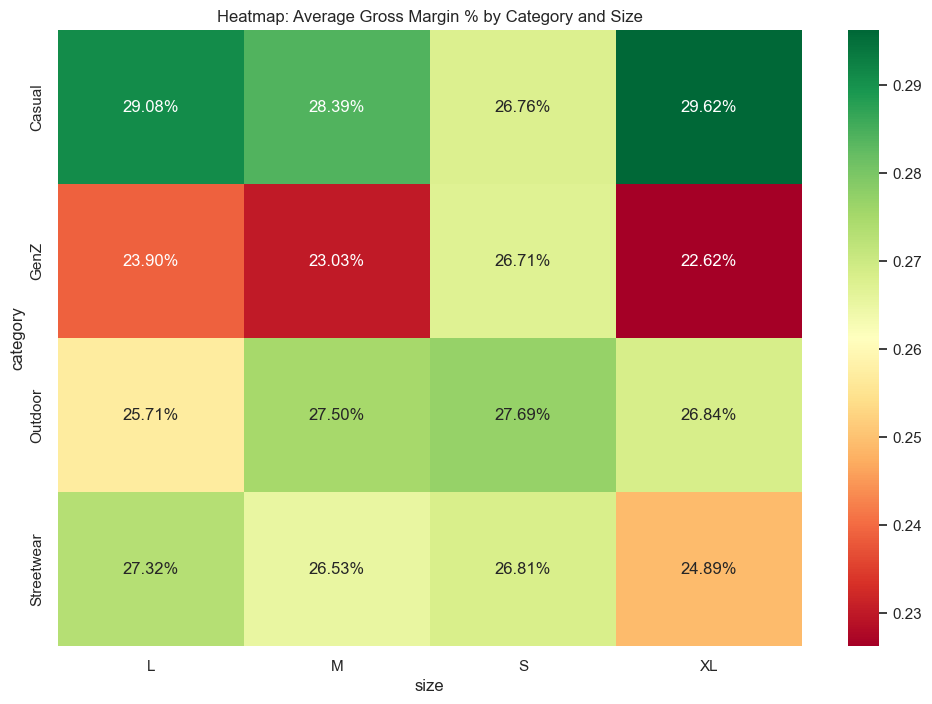

size,L,M,S,XL
category,,,,
Casual,0.290793,0.283921,0.267615,0.296212
GenZ,0.238967,0.230274,0.267132,0.226206
Outdoor,0.257061,0.274960,0.276860,0.268438
Streetwear,0.273208,0.265266,0.268067,0.248923


In [15]:
# 4. Pivot table mean gross_margin_pct theo category và size
pivot_margin = df_products.pivot_table(
    values='gross_margin_pct',
    index='category',
    columns='size',
    aggfunc='mean'
)

print("Pivot Table: Mean Gross Margin % by Category and Size")
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_margin, annot=True, fmt='.2%', cmap='RdYlGn')
plt.title('Heatmap: Average Gross Margin % by Category and Size')
plt.show()

display(pivot_margin)

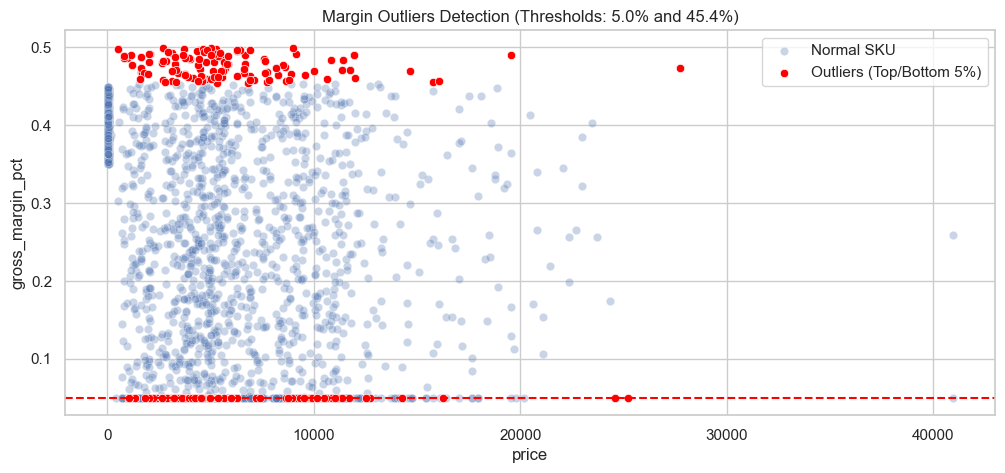

In [16]:
# 1. Outlier Margin Detection (Top & Bottom 5%)
low_threshold = df_products['gross_margin_pct'].quantile(0.05)
high_threshold = df_products['gross_margin_pct'].quantile(0.95)

outliers = df_products[(df_products['gross_margin_pct'] <= low_threshold) |
                       (df_products['gross_margin_pct'] >= high_threshold)].copy()

plt.figure(figsize=(12, 5))
sns.scatterplot(data=df_products, x='price', y='gross_margin_pct', alpha=0.3, label='Normal SKU')
sns.scatterplot(data=outliers, x='price', y='gross_margin_pct', color='red', label='Outliers (Top/Bottom 5%)')
plt.axhline(low_threshold, color='red', linestyle='--')
plt.title(f'Margin Outliers Detection (Thresholds: {low_threshold:.1%} and {high_threshold:.1%})')
plt.show()

In [ ]:
# 2. Danh mục cần tối ưu giá (Price vs Margin Benchmark)
# Benchmark chung
overall_avg_margin = df_products['gross_margin_pct'].mean()

category_summary = df_products.groupby(['category', 'segment']).agg(
    avg_price=('price', 'mean'),
    avg_margin=('gross_margin_pct', 'mean')
).reset_index()

plt.figure(figsize=(12, 6))
sns.scatterplot(data=category_summary, x='avg_price', y='avg_margin', hue='category', s=200)
plt.axhline(overall_avg_margin, color='red', linestyle='--', label='Global Margin Benchmark')
plt.title('Price vs Margin by Category/Segment: Identifying Price Optimization Candidates')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Note: Các điểm phía dưới đường màu đỏ có margin thấp hơn trung bình dù giá có thể cao.

In [ ]:
# 3. Cấu trúc size đang “ăn margin”
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_products, x='size', y='gross_margin_pct', hue='category', marker='o')
plt.title('Margin Trend by Size across Categories')
plt.ylabel('Mean Gross Margin %')
plt.grid(True, alpha=0.3)
plt.show()

# Kiểm tra tương quan COGS và Price theo Size
size_impact = df_products.groupby('size')[['price', 'cogs', 'gross_margin_pct']].mean()
display(size_impact)

In [ ]:
# 4. Price Architecture (Price Bands vs Margin)
df_products['price_band'] = pd.qcut(df_products['price'], q=5, labels=['Budget', 'Economy', 'Mid-range', 'Premium', 'Luxury'])

plt.figure(figsize=(10, 6))
sns.barplot(data=df_products, x='price_band', y='gross_margin_pct', palette='coolwarm', capsize=.1)
plt.title('Margin Performance by Price Band')
plt.ylabel('Average Gross Margin %')
plt.show()

In [ ]:
# 5. Rationalize Assortment (SKU Count vs Margin Consistency)
assortment = df_products.groupby(['category', 'segment']).agg(
    sku_count=('product_id', 'count'),
    margin_std=('gross_margin_pct', 'std'),
    avg_margin=('gross_margin_pct', 'mean')
).reset_index()

plt.figure(figsize=(12, 6))
# Kích thước bong bóng là số lượng SKU
sns.scatterplot(data=assortment, x='sku_count', y='avg_margin', size='sku_count', hue='category', sizes=(50, 1000), alpha=0.7)
plt.title('Assortment Rationalization: SKU Count vs Profitability')
plt.xlabel('Number of SKUs')
plt.ylabel('Average Margin %')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# geography.csv

In [ ]:
# 1. Descriptive Analysis cho Geography
geog_desc = df_geography.describe(include='all').T
# Đếm số lượng unique cho các cột định danh
unique_counts = df_geography[['city', 'region', 'district']].nunique().to_frame(name='unique_count')

print("Thống kê mô tả Geography:")
display(geog_desc)
print("\nSố lượng giá trị unique:")
display(unique_counts)

In [ ]:
# 2. Tổng unique zip theo từng region
region_zip = df_geography.groupby('region')['zip'].nunique().sort_values(ascending=False).reset_index(name='unique_zip_count')

# 3. Zip Count by cities
city_zip = df_geography.groupby('city')['zip'].count().sort_values(ascending=False).reset_index(name='total_zip_count')

# 4. unique zips theo từng district
district_zip = df_geography.groupby('district')['zip'].nunique().sort_values(ascending=False).reset_index(name='unique_zip_count')

print("Bảng: Unique ZIPs theo Region")
display(region_zip)

print("\nBảng: ZIP Count theo City (Top 10)")
display(city_zip.head(10))

print("\nBảng: Unique ZIPs theo District (Top 10)")
display(district_zip.head(10))

In [ ]:
# Visualization cho Geography
plt.figure(figsize=(18, 6))

# Chart 1: Unique ZIPs by Region
plt.subplot(1, 2, 1)
sns.barplot(data=region_zip, x='unique_zip_count', y='region', palette='viridis')
plt.title('Unique ZIP Codes by Region')

# Chart 2: Top 10 Districts by Unique ZIPs
plt.subplot(1, 2, 2)
sns.barplot(data=district_zip.head(10), x='unique_zip_count', y='district', palette='magma')
plt.title('Top 10 Districts by Unique ZIP Codes')

plt.tight_layout()
plt.show()

# inventory.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Preprocessing
df_inventory['snapshot_date'] = pd.to_datetime(df_inventory['snapshot_date'])

# Force product_id to string and strip any decimals to ensure match
df_inventory['product_id'] = df_inventory['product_id'].astype(str).str.split('.').str[0]
df_products['product_id'] = df_products['product_id'].astype(str).str.split('.').str[0]

# 2. DIM PRODUCT
dim_product = df_products[['product_id', 'product_name', 'category', 'segment']].drop_duplicates()
display(dim_product)

# 3. DIM CALENDAR
dim_calendar = pd.DataFrame({'snapshot_date': df_inventory['snapshot_date'].unique()})
dim_calendar['year'] = dim_calendar['snapshot_date'].dt.year
dim_calendar['month'] = dim_calendar['snapshot_date'].dt.month
dim_calendar['quarter'] = dim_calendar['snapshot_date'].dt.quarter
dim_calendar['year_month'] = dim_calendar['snapshot_date'].dt.to_period('M')
display(dim_calendar)

# 4. MONTHLY PERFORMANCE MART
inv_full = df_inventory.copy()

inv_full['year_month'] = inv_full['snapshot_date'].dt.to_period('M')

# 3. Xử lý is_stockout an toàn:
if 'stockout_flag' in inv_full.columns:
    # Nếu BTC đã cho sẵn cột flag, ưu tiên dùng nó
    inv_full['is_stockout'] = inv_full['stockout_flag'].astype(int)
else:
    # Nếu không có, tự tính và bao phòng lỗi định dạng kiểu số/null
    inv_full['stock_on_hand'] = pd.to_numeric(inv_full['stock_on_hand'], errors='coerce').fillna(0)
    inv_full['is_stockout'] = (inv_full['stock_on_hand'] == 0).astype(int)

monthly_mart = inv_full.groupby(['product_id', 'year_month']).agg(
    avg_stock_level=('stock_on_hand', 'mean'),
    total_units_received=('units_received', 'sum'),
    total_units_sold=('units_sold', 'sum'),
    stockout_days=('is_stockout', 'sum'),
    days_in_month=('snapshot_date', 'count')
).reset_index()

# KPIs
monthly_mart['stockout_rate'] = monthly_mart['stockout_days'] / monthly_mart['days_in_month']
monthly_mart['avg_days_of_supply'] = np.where(monthly_mart['total_units_sold'] > 0,
                                            (monthly_mart['avg_stock_level'] / (monthly_mart['total_units_sold']/30)), 0)

print("Monthly Performance Mart (First 5 rows):")
display(monthly_mart.head())

In [ ]:
# 5. CATEGORY/SEGMENT SCORECARD
category_scorecard = inv_full.groupby(['category', 'segment']).agg(
    avg_stock_level=('stock_on_hand', 'mean'),
    total_sold=('units_sold', 'sum'),
    avg_stockout_rate=('is_stockout', 'mean')
).reset_index()

print("Category/Segment Scorecard:")
display(category_scorecard.sort_values('avg_stockout_rate', ascending=False))

# 6. PRODUCT RISK TABLE
product_risk = inv_full.groupby(['product_id', 'product_name', 'category']).agg(
    total_units_sold=('units_sold', 'sum'),
    stockout_rate=('is_stockout', 'mean')
).reset_index()

# Identify Risk: High Sales with High Stockout Rate
max_sales = product_risk['total_units_sold'].max()
product_risk['risk_score'] = (product_risk['total_units_sold'] / max_sales) * product_risk['stockout_rate']
product_risk = product_risk.sort_values('risk_score', ascending=False).reset_index(drop=True)

print("Product Risk Table (Top 10 High Risk SKUs):")
display(product_risk.head(10))

In [ ]:
# 7. VISUALIZATION
plt.figure(figsize=(16, 6))

# Chart 1: Stockout Rate vs Units Sold by Category
plt.subplot(1, 2, 1)
sns.scatterplot(data=category_scorecard, x='total_sold', y='avg_stockout_rate', hue='category', s=200)
plt.title('Category Risk: Volume vs Stockout Rate')

# Chart 2: Inventory Trend (Total Stock vs Total Sold)
trend_data = inv_full.groupby('snapshot_date').agg({'stock_on_hand':'sum', 'units_sold':'sum'}).reset_index()
plt.subplot(1, 2, 2)
plt.plot(trend_data['snapshot_date'], trend_data['stock_on_hand'], label='Total Stock')
plt.plot(trend_data['snapshot_date'], trend_data['units_sold'], label='Total Sold')
plt.legend()
plt.title('Daily Inventory vs Sales Trend')

plt.tight_layout()
plt.show()

# customer.csv

In [ ]:
# 1. Tiền xử lý dữ liệu thời gian và Descriptive Analysis
df_custormers['signup_date'] = pd.to_datetime(df_custormers['signup_date'])
# Bỏ tham số datetime_is_numeric để tránh lỗi tương thích phiên bản
display(df_custormers.describe(include='all'))

In [ ]:
# 2. Customer Mix Overview
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Acquisition Channel
sns.countplot(data=df_custormers, y='acquisition_channel', order=df_custormers['acquisition_channel'].value_counts().index, ax=axes[0,0], palette='viridis')
axes[0,0].set_title('Customers by Acquisition Channel')

# Top 10 Cities
top_cities = df_custormers['city'].value_counts().nlargest(10).index
sns.countplot(data=df_custormers[df_custormers['city'].isin(top_cities)], y='city', order=top_cities, ax=axes[0,1], palette='magma')
axes[0,1].set_title('Top 10 Cities by Customer Count')

# Gender
df_custormers['gender'].value_counts().plot.pie(autopct='%1.1f%%', ax=axes[1,0], colors=['skyblue', 'pink', 'lightgrey'])
axes[1,0].set_title('Customer Mix by Gender')

# Age Group
sns.countplot(data=df_custormers, x='age_group', order=sorted(df_custormers['age_group'].unique()), ax=axes[1,1], palette='cubehelix')
axes[1,1].set_title('Customer Mix by Age Group')

plt.tight_layout()
plt.show()

In [ ]:
# 3. New Customers over time
df_custormers['signup_month'] = df_custormers['signup_date'].dt.to_period('M')
monthly_growth = df_custormers.groupby('signup_month').size()

plt.figure(figsize=(15, 6))
monthly_growth.plot(kind='line', marker='.', color='teal')
plt.title('New Customers Growth Over Time (Monthly)')
plt.ylabel('Number of New Customers')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# 4. Channel Mix over time (Yearly for clarity)
df_custormers['signup_year'] = df_custormers['signup_date'].dt.year
channel_mix_time = pd.crosstab(df_custormers['signup_year'], df_custormers['acquisition_channel'], normalize='index')

channel_mix_time.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='tab10')
plt.title('Acquisition Channel Mix Evolution Over Years')
plt.ylabel('Percentage Share')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

In [ ]:
# 5. Acquisition channel share by Age group and Gender
# Age x Channel
age_channel_pct = pd.crosstab(df_custormers['age_group'], df_custormers['acquisition_channel'], normalize='index')

# Gender x Channel
gender_channel_pct = pd.crosstab(df_custormers['gender'], df_custormers['acquisition_channel'], normalize='index')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

sns.heatmap(age_channel_pct, annot=True, fmt='.1%', cmap='YlGnBu', ax=ax1)
ax1.set_title('Channel Share by Age Group (Row-Normalized)')

sns.heatmap(gender_channel_pct, annot=True, fmt='.1%', cmap='PuRd', ax=ax2)
ax2.set_title('Channel Share by Gender (Row-Normalized)')

plt.tight_layout()
plt.show()

# promotions.csv + orders.csv

In [ ]:
# 2. Preprocessing
df_promotions['start_date'] = pd.to_datetime(df_promotions['start_date'])
df_promotions['end_date'] = pd.to_datetime(df_promotions['end_date'])
df_promotions['duration_value'] = (df_promotions['end_date'] - df_promotions['start_date']).dt.days
df_orders['order_date'] = pd.to_datetime(df_orders['order_date'])

# 3. Descriptive Analysis
# Lọc các cột cần thiết
promo_cols = ['promo_type', 'discount_value', 'start_date', 'end_date', 'applicable_category', 'promo_channel', 'stackable_flag', 'min_order_value']
# Bỏ datetime_is_numeric=True để tránh lỗi version
descriptive_promo = df_promotions[promo_cols].describe(include='all').T
display(descriptive_promo)

In [ ]:
# 4. Bảng tổng hợp theo Channel & Type
channel_analysis = df_promotions.groupby('promo_channel').agg(
    count=('promo_id', 'count'),
    avg_discount=('discount_value', 'mean'),
    avg_duration=('duration_value', 'mean'),
    avg_min_order=('min_order_value', 'mean'),
    stackable_rate=('stackable_flag', 'mean')
).reset_index()

type_analysis = df_promotions.groupby('promo_type').agg(
    count=('promo_id', 'count'),
    avg_discount=('discount_value', 'mean'),
    avg_min_order=('min_order_value', 'mean')
).reset_index()

print("Phân tích theo Channel:")
display(channel_analysis)
print("Phân tích theo Type:")
display(type_analysis)

In [ ]:
# 5. Correlation Heatmap
corr_cols = ['discount_value', 'min_order_value', 'stackable_flag', 'duration_value']
plt.figure(figsize=(10, 6))
sns.heatmap(df_promotions[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation: Discount vs Min Order vs Duration')
plt.show()

In [ ]:
# 6. Order Analysis
# Số order theo thời gian
df_orders['order_month'] = df_orders['order_date'].dt.to_period('M')
monthly_orders = df_orders.groupby('order_month').size()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
# Order Status
sns.countplot(data=df_orders, x='order_status', ax=axes[0], palette='pastel')
axes[0].set_title('Order Status Distribution')
# Monthly Trend
monthly_orders.plot(ax=axes[1], marker='o', color='orange')
axes[1].set_title('Orders by Month')
plt.show()

In [ ]:
# 7. Strategic Insights: Discount vs Margin Control
# Giả định: Nối promo với products qua applicable_category để xem margin ảnh hưởng thế nào
category_margin = df_products.groupby('category')['gross_margin_pct'].mean().reset_index()
promo_cat_avg = df_promotions.groupby('applicable_category')['discount_value'].mean().reset_index()

merged_insight = pd.merge(category_margin, promo_cat_avg, left_on='category', right_on='applicable_category')

plt.figure(figsize=(12, 6))
sns.regplot(data=merged_insight, x='discount_value', y='gross_margin_pct')
for i in range(merged_insight.shape[0]):
    plt.text(merged_insight.discount_value[i], merged_insight.gross_margin_pct[i], merged_insight.category[i])

plt.title('Potential Margin Erosion: Avg Discount vs Avg Margin by Category')
plt.show()

# returns.csv


In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Tạo metrics (Giả sử các cột gốc là quantity và refund_value)
df_returns['return_flag'] = 1
# Đảm bảo tên cột khớp với schema thực tế (refund_amount và return_quantity)
# Nếu cột có tên khác, ta sẽ rename hoặc giữ nguyên tùy theo file
display(df_returns.head())

# 3. Descriptive Analysis
stats_returns = df_returns[['return_quantity', 'refund_amount']].describe()
stats_returns.loc['median'] = df_returns[['return_quantity', 'refund_amount']].median()
display(stats_returns)

In [ ]:
# 4. Bảng tổng hợp theo Return Reason
reason_analysis = df_returns.groupby('return_reason').agg(
    total_returns=('return_flag', 'sum'),
    total_refund=('refund_amount', 'sum'),
    avg_refund=('refund_amount', 'mean')
).sort_values(by='total_refund', ascending=False).reset_index()

# Tính % đóng góp
reason_analysis['refund_share_pct'] = (reason_analysis['total_refund'] / reason_analysis['total_refund'].sum()) * 100

print("Phân tích theo Lý do trả hàng:")
display(reason_analysis)

In [ ]:
# 5. Return by Category (Cần merge với df_products)
df_returns_merged = pd.merge(df_returns, df_products[['product_id', 'product_name', 'category']], on='product_id', how='left')

cat_returns = df_returns_merged.groupby('category').agg(
    return_count=('return_flag', 'sum'),
    total_refund=('refund_amount', 'sum')
).sort_values(by='total_refund', ascending=False).reset_index()

print("Phân tích trả hàng theo Category:")
display(cat_returns)

In [ ]:
# 6. Visualizations
plt.figure(figsize=(20, 12))

# Chart 1: Refund Amount Distribution (Detecting Outliers)
plt.subplot(2, 2, 1)
sns.histplot(df_returns['refund_amount'], kde=True, color='red')
plt.title('Distribution of Refund Amounts')

# Chart 2: Total Refund by Reason
plt.subplot(2, 2, 2)
sns.barplot(data=reason_analysis, x='total_refund', y='return_reason', palette='magma')
plt.title('Total Refund Value by Reason')

# Chart 3: Return Reason vs Category (Heatmap)
pivot_reason_cat = df_returns_merged.pivot_table(index='return_reason', columns='category', values='return_flag', aggfunc='sum', fill_value=0)
plt.subplot(2, 2, 3)
sns.heatmap(pivot_reason_cat, annot=True, fmt='d', cmap='YlOrRd')
plt.title('Heatmap: Reason vs Category (Frequency)')

# Chart 4: Refund Outliers Boxplot
plt.subplot(2, 2, 4)
sns.boxplot(x='category', y='refund_amount', data=df_returns_merged)
plt.xticks(rotation=45)
plt.title('Refund Amount Outliers by Category')

plt.tight_layout()
plt.show()

### Strategic Insights từ dữ liệu Returns:
- **Lý do trả hàng:** Nếu 'Defective' hoặc 'Wrong Item' chiếm đa số, vấn đề nằm ở **Vận hành/Kho bãi**. Nếu 'Not as described' cao, cần kiểm tra lại **Marketing/Hình ảnh sản phẩm**.
- **Thiệt hại tài chính:** Kiểm tra xem 20% số case trả hàng có chiếm 80% tổng giá trị refund không (Pareto). Các case refund cực cao (outliers) cần được kiểm soát riêng.
- **Sản phẩm/Category trọng điểm:** Các category có margin thấp nhưng tỷ lệ trả hàng cao sẽ là những nhóm gây lỗ ròng, cần loại bỏ khỏi danh mục hoặc tối ưu lại quy trình kiểm soát chất lượng.

# shipments.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# 1. COPY DATA (tránh modify gốc)
# ==============================
df = df_shipments.copy()

# ==============================
# 2. CLEAN DATETIME
# ==============================
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce')
df['delivery_date'] = pd.to_datetime(df['delivery_date'], errors='coerce')

# Drop dòng lỗi ngày
df = df.dropna(subset=['ship_date', 'delivery_date'])

# ==============================
# 3. FEATURE ENGINEERING
# ==============================
df['delivery_days'] = (df['delivery_date'] - df['ship_date']).dt.days

# Loại bỏ dữ liệu bất thường
df = df[df['delivery_days'] >= 0]

# ==============================
# 4. DESCRIPTIVE STATS
# ==============================
shipment_stats = df[['delivery_days', 'shipping_fee']].describe().T
shipment_stats['median'] = df[['delivery_days', 'shipping_fee']].median()

print("Thống kê mô tả Shipments:")
display(shipment_stats)

# ==============================
# 5. FIX DUPLICATE KEYS TRƯỚC MERGE
# ==============================
df_orders_clean = df_orders.drop_duplicates(subset='order_id')
df_customers_clean = df_customers.drop_duplicates(subset='customer_id')
df_geo_clean = df_geography.drop_duplicates(subset='city')

# ==============================
# 6. MERGE AN TOÀN
# ==============================
df_ship_geo = df.merge(
    df_orders_clean[['order_id', 'customer_id']],
    on='order_id',
    how='left'
)

df_ship_geo = df_ship_geo.merge(
    df_customers_clean[['customer_id', 'city']],
    on='customer_id',
    how='left'
)

df_ship_geo = df_ship_geo.merge(
    df_geo_clean,
    on='city',
    how='left'
)

# ==============================
# 7. CHECK DATA SAU MERGE
# ==============================
print("Rows trước merge:", len(df))
print("Rows sau merge:", len(df_ship_geo))

# ==============================
# 8. GROUPBY ANALYSIS
# ==============================
region_perf = df_ship_geo.groupby('region', dropna=False).agg(
    avg_delivery_days=('delivery_days', 'mean'),
    median_delivery_days=('delivery_days', 'median'),
    avg_shipping_fee=('shipping_fee', 'mean'),
    total_orders=('order_id', 'count')
).reset_index().sort_values('avg_delivery_days', ascending=False)

print("Hiệu suất giao hàng theo Vùng miền:")
display(region_perf)

# ==============================
# 9. VISUALIZATION (OPTIMIZED)
# ==============================
# Lấy sample để tránh lag
sample_df = df.sample(min(50000, len(df)), random_state=42)

plt.figure(figsize=(18, 5))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(sample_df['delivery_days'], kde=True)
plt.title('Distribution of Delivery Days')

# Scatter
plt.subplot(1, 2, 2)
sns.scatterplot(
    data=sample_df,
    x='delivery_days',
    y='shipping_fee',
    alpha=0.3
)
plt.title('Shipping Fee vs Delivery Days')

plt.tight_layout()
plt.show()

# payments.csv

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Thống kê mô tả (Descriptive Analysis)
# Xem xét giá trị thanh toán và số kỳ trả góp
payment_stats = df_payments[['payment_value', 'installments']].describe().T
payment_stats['median'] = df_payments[['payment_value', 'installments']].median()
print("Thống kê mô tả Payments:")
display(payment_stats)

# 2. Tổng hợp theo Payment Method
method_analysis = df_payments.groupby('payment_method').agg(
    count=('order_id', 'count'),
    avg_payment_value=('payment_value', 'mean'),
    total_revenue=('payment_value', 'sum')
).reset_index().sort_values(by='count', ascending=False)

method_analysis['share_pct'] = (method_analysis['count'] / method_analysis['count'].sum()) * 100
print("Phân tích theo Phương thức thanh toán:")
display(method_analysis)

# 3. Mối liên hệ giữa Installments và Giá trị đơn hàng (AOV)
installments_impact = df_payments.groupby('installments').agg(
    count=('order_id', 'count'),
    avg_payment_value=('payment_value', 'mean')
).reset_index()

# 4. Visualization
plt.figure(figsize=(20, 12))

# Chart 1: Distribution of Payment Value (Log scale để dễ nhìn nếu có outlier)
plt.subplot(2, 2, 1)
sns.histplot(df_payments['payment_value'], bins=50, kde=True, color='green')
plt.title('Distribution of Payment Value')

# Chart 2: Payment Method Share
plt.subplot(2, 2, 2)
plt.pie(method_analysis['count'], labels=method_analysis['payment_method'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Payment Method Market Share')

# Chart 3: Avg Payment Value by Method
plt.subplot(2, 2, 3)
sns.barplot(data=method_analysis, x='payment_method', y='avg_payment_value', palette='magma')
plt.title('Average Order Value by Payment Method')

# Chart 4: Installments vs Avg Payment Value (Kiểm tra xem trả góp có tăng AOV không)
plt.subplot(2, 2, 4)
sns.lineplot(data=installments_impact, x='installments', y='avg_payment_value', marker='o', color='red')
plt.title('Installments vs Average Payment Value (AOV)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Potential Insights
print("Potential Insights:")
high_val_method = method_analysis.sort_values(by='avg_payment_value', ascending=False).iloc[0]['payment_method']
print(f"- Phương thức mang lại giá trị đơn hàng cao nhất: {high_val_method}")
if installments_impact.corr().loc['installments', 'avg_payment_value'] > 0.5:
    print("- Xu hướng: Số kỳ trả góp càng cao thường đi kèm với giá trị đơn hàng càng lớn (Tăng AOV).")

# review.csv

In [ ]:

import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data
reviews_path = os.path.join(data_path, 'reviews.csv')
df_reviews = pd.read_csv(reviews_path)

# 2. Tạo rating_bucket
def get_rating_bucket(rating):
    if rating <= 2: return 'Low (1-2)'
    elif rating == 3: return 'Mid (3)'
    else: return 'High (4-5)'

df_reviews['rating_bucket'] = df_reviews['rating'].apply(get_rating_bucket)

# 3. Descriptive Analysis cho rating
print("Descriptive Stats for Rating:")
rating_stats = df_reviews['rating'].describe().to_frame().T
rating_stats['median'] = df_reviews['rating'].median()
display(rating_stats)

# 4. Rating Distribution
rating_dist = df_reviews['rating'].value_counts(normalize=True).sort_index() * 100
print("\nRating Distribution (%):")
display(rating_dist)

# 5. Merge với Products để phân tích theo Category
df_reviews_merged = df_reviews.merge(df_products[['product_id', 'category']], on='product_id', how='left')

# 6. Average Rating theo Category
cat_rating = df_reviews_merged.groupby('category').agg(
    avg_rating=('rating', 'mean'),
    n_reviews=('review_id', 'count'),
    low_rating_pct=('rating', lambda x: (x <= 2).mean() * 100)
).sort_values(by='avg_rating').reset_index()

print("\nAverage Rating by Category:")
display(cat_rating)

# 7. Visualization
plt.figure(figsize=(20, 12))

# Chart 1: Rating Distribution (Pie & Count)
plt.subplot(2, 2, 1)
sns.countplot(data=df_reviews, x='rating', palette='RdYlGn')
plt.title('Count of Ratings (Satisfaction Level)')

# Chart 2: Rating Buckets Share
plt.subplot(2, 2, 2)
df_reviews['rating_bucket'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Rating Buckets Distribution')

# Chart 3: Avg Rating by Category
plt.subplot(2, 2, 3)
sns.barplot(data=cat_rating, x='avg_rating', y='category', palette='viridis')
plt.title('Average Rating by Category')

# Chart 4: Low Rating % vs Avg Rating (Identify Problematic Categories)
plt.subplot(2, 2, 4)
sns.scatterplot(data=cat_rating, x='avg_rating', y='low_rating_pct', size='n_reviews', hue='category', sizes=(100, 1000))
plt.axhline(df_reviews['rating'].apply(lambda x: x <= 2).mean() * 100, color='red', linestyle='--', label='Avg Low Rating %')
plt.title('Category Risk: Avg Rating vs % of Low Ratings')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# 8. Liên kết với Returns (Giả định có return data để check quality correlation)
if 'df_returns_merged' in locals():
    # Tính return rate cho mỗi sản phẩm từ df_returns
    return_counts = df_returns.groupby('product_id').size().reset_index(name='return_count')
    # Tính avg rating cho mỗi sản phẩm
    product_rating = df_reviews.groupby('product_id')['rating'].mean().reset_index(name='avg_rating')

    # Merge
    quality_link = product_rating.merge(return_counts, on='product_id', how='inner')

    plt.figure(figsize=(10, 6))
    sns.regplot(data=quality_link, x='avg_rating', y='return_count', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
    plt.title('Correlation: Product Avg Rating vs Return Frequency')
    plt.show()


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tính toán Metrics cấp độ Sản phẩm
# Tính Rating trung bình cho mỗi sản phẩm
product_rating_stats = df_reviews.groupby('product_id')['rating'].agg(['mean', 'count']).rename(columns={'mean': 'avg_rating', 'count': 'review_count'})

# Tính số lượng trả hàng cho mỗi sản phẩm
product_return_stats = df_returns.groupby('product_id').size().to_frame('return_count')

# 2. Kết hợp dữ liệu (Inner join để đảm bảo sản phẩm có cả review và return)
quality_analysis = product_rating_stats.join(product_return_stats, how='inner').reset_index()

# 3. Phân tích tương quan
correlation_value = quality_analysis['avg_rating'].corr(quality_analysis['return_count'])

# 4. Trực quan hóa
plt.figure(figsize=(12, 6))
sns.regplot(data=quality_analysis, x='avg_rating', y='return_count',
            scatter_kws={'alpha':0.4, 'color':'teal'},
            line_kws={'color':'red', 'label': f'Trendline (Corr: {correlation_value:.2f})'})

plt.title('Correlation Analysis: Product Avg Rating vs. Return Frequency', fontsize=14)
plt.xlabel('Average Rating (Customer Satisfaction)', fontsize=12)
plt.ylabel('Total Returns Count', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

print(f"Hệ số tương quan (Correlation Coefficient): {correlation_value:.2f}")
if correlation_value < -0.3:
    print("\n=> KẾT LUẬN: Có mối tương quan âm rõ rệt. Rating càng thấp thì số lượng trả hàng càng cao. Customer Satisfaction là chỉ số dự báo quan trọng cho rủi ro hoàn hàng.")
elif correlation_value > -0.3 and correlation_value < 0:
    print("\n=> KẾT LUẬN: Có xu hướng tương quan âm nhẹ nhưng không quá mạnh. Có thể còn các yếu tố khác (vận chuyển, kích cỡ) ảnh hưởng đến return.")
else:
    print("\n=> KẾT LUẬN: Không thấy mối liên hệ tuyến tính rõ ràng giữa Rating và Return trong tập dữ liệu này.")

# order_items.csv

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 2. Feature Engineering
df_order_items['gross_item_value'] = df_order_items['quantity'] * df_order_items['unit_price']
df_order_items['net_item_value'] = df_order_items['gross_item_value'] - df_order_items['discount_amount']
df_order_items['has_promo'] = df_order_items['promo_id'].notnull()

# 3. Descriptive Analysis
cols_to_desc = ['quantity', 'unit_price', 'gross_item_value', 'discount_amount', 'net_item_value']
descriptive_order_items = df_order_items[cols_to_desc].describe().T
descriptive_order_items['median'] = df_order_items[cols_to_desc].median()

print("Thống kê mô tả Order Items:")
display(descriptive_order_items)

### Detailed Distribution Analysis of Order Items

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the visualization grid
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Quantity Distribution
sns.histplot(df_order_items['quantity'], bins=20, kde=False, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Quantity Distribution (Items per SKU per Order)')
axes[0, 0].set_xlabel('Quantity')

# 2. Unit Price Distribution
sns.histplot(df_order_items['unit_price'], bins=50, kde=True, ax=axes[0, 1], color='salmon')
axes[0, 1].set_title('Unit Price Distribution (Actual Selling Price)')
axes[0, 1].set_xlabel('Price')

# 3. Revenue (Net Item Value) Distribution
sns.histplot(df_order_items['net_item_value'], bins=50, kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title('Revenue per Item Distribution')
axes[1, 0].set_xlabel('Net Item Value')

# 4. Discount Distribution
# We filter for records that actually have a discount to see the spread of discount values
discounts_only = df_order_items[df_order_items['discount_amount'] > 0]['discount_amount']
sns.histplot(discounts_only, bins=50, kde=True, ax=axes[1, 1], color='gold')
axes[1, 1].set_title('Discount Amount Distribution (Where applied)')
axes[1, 1].set_xlabel('Discount Amount')

plt.tight_layout()
plt.show()

In [ ]:
# 4. Tổng hợp theo Product & Category (Join với df_products)
df_oi_merged = df_order_items.merge(df_products[['product_id', 'category', 'product_name']], on='product_id', how='left')

# Revenue theo Category
cat_rev = df_oi_merged.groupby('category').agg(
    total_revenue=('net_item_value', 'sum'),
    avg_unit_price=('unit_price', 'mean'),
    total_qty=('quantity', 'sum')
).sort_values(by='total_revenue', ascending=False).reset_index()

# Revenue theo Product (Top 10)
prod_rev = df_oi_merged.groupby('product_name').agg(
    total_revenue=('net_item_value', 'sum'),
    total_qty=('quantity', 'sum')
).sort_values(by='total_revenue', ascending=False).head(10).reset_index()

# Promo vs Non-Promo Impact
promo_impact = df_oi_merged.groupby('has_promo').agg(
    avg_net_value=('net_item_value', 'mean'),
    total_revenue=('net_item_value', 'sum'),
    order_count=('order_id', 'count')
).reset_index()

print("Phân tích doanh thu theo Category:")
display(cat_rev)
print("Top 10 Sản phẩm doanh thu cao nhất:")
display(prod_rev)

In [ ]:
# Tính Revenue theo từng đơn hàng (Order Value)
order_revenue = df_order_items.groupby('order_id')['net_item_value'].sum().reset_index()

# Tính AOV (Average Order Value)
aov_value = order_revenue['net_item_value'].mean()
median_ov = order_revenue['net_item_value'].median()

print(f"Average Order Value (AOV): {aov_value:,.2f}")
print(f"Median Order Value: {median_ov:,.2f}")

# Trực quan hóa phân phối giá trị đơn hàng
plt.figure(figsize=(10, 6))
sns.histplot(order_revenue['net_item_value'], bins=100, kde=True, color='blue')
plt.axvline(aov_value, color='red', linestyle='--', label=f'AOV: {aov_value:,.0f}')
plt.title('Distribution of Order Revenue (AOV Analysis)')
plt.xlabel('Order Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
# 5. Visualizations
plt.figure(figsize=(20, 15))

# Chart 1: Pareto Principle - Revenue Concentration by Product
plt.subplot(2, 2, 1)
prod_rev['cum_pct'] = prod_rev['total_revenue'].cumsum() / df_oi_merged['net_item_value'].sum() * 100
sns.barplot(data=prod_rev, x='total_revenue', y='product_name', palette='Blues_r')
plt.title('Top 10 Revenue Generating Products')

# Chart 2: Promo vs Non-Promo Revenue Share
plt.subplot(2, 2, 2)
labels = ['Non-Promo', 'Promo']
plt.pie(promo_impact['total_revenue'], labels=labels, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('Revenue Share: Promo vs Non-Promo')

# Chart 3: Basket Size (AOV calculation logic)
order_aov = df_order_items.groupby('order_id')['net_item_value'].sum()
plt.subplot(2, 2, 3)
sns.histplot(order_aov, bins=50, kde=True, color='purple')
plt.title('Order Value Distribution (Basket Size)')
plt.xlabel('Net Order Value')

# Chart 4: Pricing Power (Volume vs Price by Category)
plt.subplot(2, 2, 4)
sns.barplot(
    data=cat_rev,
    x='category',
    y='total_revenue'
)
plt.title('Category Strategy: Price vs Volume')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Strategic Deep Dive: Promo Efficiency & Product Profitability

In [ ]:
# 1. Promo Effectiveness: Do discounts drive enough volume to justify margin loss?
promo_analysis = df_oi_merged.groupby('has_promo').agg(
    avg_qty=('quantity', 'mean'),
    avg_net_value=('net_item_value', 'mean'),
    total_revenue=('net_item_value', 'sum'),
    count=('order_id', 'count')
).reset_index()

display(promo_analysis)

# 2. Buying Pattern: Cheap/Bulk vs expensive/Niche
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_order_items.sample(1000), x='unit_price', y='quantity', alpha=0.5)
plt.title('Price vs Quantity: Buying Patterns')
plt.show()

In [ ]:
# 3. Low Efficiency Products (High Volume, Low Profit)
# Merge with product info for COGS
df_profit = df_oi_merged.merge(df_products[['product_id', 'cogs']], on='product_id', how='left')
df_profit['total_cogs'] = df_profit['quantity'] * df_profit['cogs']
df_profit['total_profit'] = df_profit['net_item_value'] - df_profit['total_cogs']

prod_efficiency = df_profit.groupby(['product_id', 'product_name', 'category']).agg(
    total_qty=('quantity', 'sum'),
    total_revenue=('net_item_value', 'sum'),
    total_profit=('total_profit', 'sum')
).reset_index()

# Identify items with high volume but profit margin < 10%
prod_efficiency['margin_pct'] = prod_efficiency['total_profit'] / prod_efficiency['total_revenue']

print("Top 10 High Volume products with Low Margin (Potential Inefficiency):")
display(prod_efficiency[prod_efficiency['total_qty'] > prod_efficiency['total_qty'].median()].sort_values('margin_pct').head(10))

### Strategic Insights từ Order Items:
- **Sự tập trung doanh thu**: Biểu đồ Pareto giúp nhận diện liệu doanh thu có đang bị phụ thuộc quá nhiều vào một vài SKU cụ thể hay không.
- **Hiệu quả khuyến mãi**: Nếu tỷ trọng doanh thu từ Promo cao nhưng Net Value trung bình thấp, cần xem xét lại liệu khuyến mãi có đang thực sự mang lại lợi nhuận hay chỉ đang 'đốt' Margin.
- **Pricing Power**: Các Category nằm ở góc trên bên phải (Giá cao & Volume lớn) là những nhóm có sức mạnh thương hiệu tốt.
- **Basket Size**: Nếu phân phối tập trung ở vùng giá trị thấp, đây là cơ hội để triển khai các chiến dịch Bundle hoặc Upsell.